# Importing Required Libraries

In [4]:
# ============================================================
# BLOCK 1: IMPORT LIBRARIES AND DEFINE DATASET PATHS
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Original classification dataset paths
# ------------------------------------------------------------

TRAIN_PATH = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification\train"
)

TEST_PATH = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification\test"
)

# ------------------------------------------------------------
# Folder where preprocessed images will be saved
# IMPORTANT:
# We do NOT modify the original dataset.
# ------------------------------------------------------------

OUTPUT_BASE = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification_Preprocessed"
)

PREPROCESSED_TRAIN_PATH = OUTPUT_BASE / "train"
PREPROCESSED_TEST_PATH = OUTPUT_BASE / "test"

# ------------------------------------------------------------
# Image size used throughout the project
# ------------------------------------------------------------

IMG_SIZE = (256, 256)

# ------------------------------------------------------------
# Check whether the input folders exist
# ------------------------------------------------------------

print("Train path exists :", TRAIN_PATH.exists())
print("Test path exists  :", TEST_PATH.exists())

# ------------------------------------------------------------
# Create output folders
# ------------------------------------------------------------

PREPROCESSED_TRAIN_PATH.mkdir(parents=True, exist_ok=True)
PREPROCESSED_TEST_PATH.mkdir(parents=True, exist_ok=True)

print("\nOutput directory:")
print(OUTPUT_BASE)

print("\nImage size:", IMG_SIZE)

Train path exists : True
Test path exists  : True

Output directory:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification_Preprocessed

Image size: (256, 256)


# Image count

In [5]:
# ============================================================
# BLOCK 2: CHECK DATASET CLASSES AND IMAGE COUNTS
# ============================================================

# Supported image extensions
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# ------------------------------------------------------------
# Function to inspect one dataset split
# ------------------------------------------------------------

def inspect_dataset(dataset_path, dataset_name):
    
    print("=" * 60)
    print(f"{dataset_name.upper()} DATASET")
    print("=" * 60)
    
    # Get class folders
    class_folders = sorted([
        folder for folder in dataset_path.iterdir()
        if folder.is_dir()
    ])
    
    print(f"\nNumber of classes: {len(class_folders)}")
    
    # Display class names
    print("\nClasses:")
    for folder in class_folders:
        print(" -", folder.name)
    
    print("\nImage counts:")
    
    total_images = 0
    
    # Count images inside every class
    for class_folder in class_folders:
        
        image_files = [
            file for file in class_folder.iterdir()
            if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
        ]
        
        count = len(image_files)
        total_images += count
        
        print(f"{class_folder.name:20s}: {count}")
    
    print("-" * 60)
    print(f"Total images: {total_images}")
    
    return class_folders


# ------------------------------------------------------------
# Inspect training dataset
# ------------------------------------------------------------

train_classes = inspect_dataset(
    TRAIN_PATH,
    "Training"
)


# ------------------------------------------------------------
# Inspect testing dataset
# ------------------------------------------------------------

test_classes = inspect_dataset(
    TEST_PATH,
    "Testing"
)

TRAINING DATASET

Number of classes: 3

Classes:
 - glioma
 - meningioma
 - pituitary

Image counts:
glioma              : 1147
meningioma          : 1329
pituitary           : 1457
------------------------------------------------------------
Total images: 3933
TESTING DATASET

Number of classes: 3

Classes:
 - glioma
 - meningioma
 - pituitary

Image counts:
glioma              : 254
meningioma          : 306
pituitary           : 300
------------------------------------------------------------
Total images: 860


# visualize images

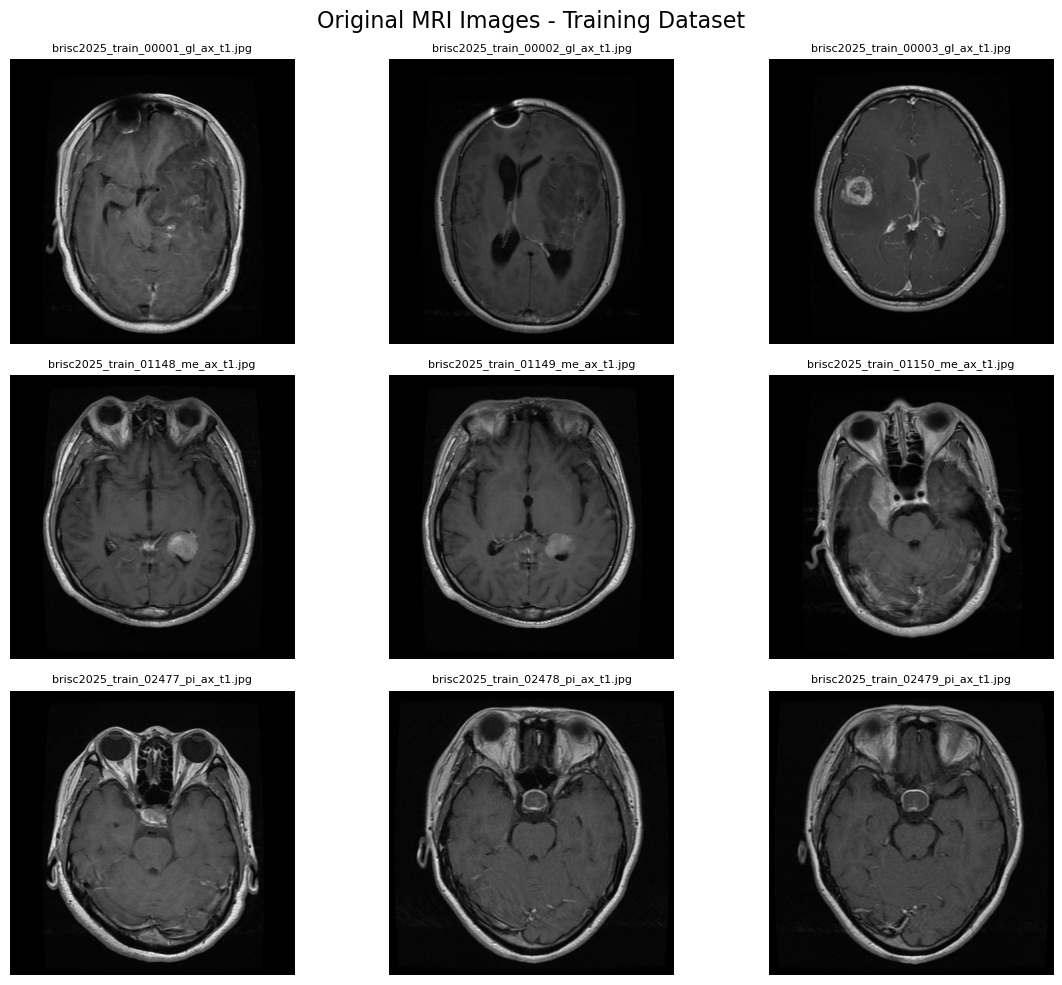

In [6]:
# ============================================================
# BLOCK 3: VISUALIZE ORIGINAL MRI IMAGES
# ============================================================

# Number of images to display from each class
NUM_IMAGES = 3

# Create one figure for the training dataset
fig, axes = plt.subplots(
    len(train_classes),
    NUM_IMAGES,
    figsize=(12, 10)
)

fig.suptitle(
    "Original MRI Images - Training Dataset",
    fontsize=16
)

# ------------------------------------------------------------
# Loop through each tumor class
# ------------------------------------------------------------

for row, class_folder in enumerate(train_classes):

    # Get image files from the current class
    image_files = [
        file for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Take first few images
    selected_images = image_files[:NUM_IMAGES]

    for col, image_path in enumerate(selected_images):

        # Read image in grayscale
        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        # Display image
        axes[row, col].imshow(
            image,
            cmap="gray"
        )

        axes[row, col].axis("off")

        # Show class name on the first image
        if col == 0:
            axes[row, col].set_ylabel(
                class_folder.name,
                fontsize=12
            )

        axes[row, col].set_title(
            image_path.name,
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# BLOCK 4: CHECK IMAGE PROPERTIES
# ============================================================
# This block checks:
# 1. Image dimensions
# 2. Number of channels
# 3. Pixel value range
# 4. Image data type
#
# We will use this information to decide the correct
# preprocessing operations.
# ============================================================

# ------------------------------------------------------------
# Select a few images from the training dataset
# ------------------------------------------------------------

sample_images = []

for class_folder in train_classes:

    image_files = [
        file for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Take first 2 images from each class
    sample_images.extend(image_files[:2])


# ------------------------------------------------------------
# Inspect each selected image
# ------------------------------------------------------------

print("=" * 70)
print("IMAGE PROPERTY INSPECTION")
print("=" * 70)

for image_path in sample_images:

    # Read image without forcing grayscale
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_UNCHANGED
    )

    # Check whether OpenCV successfully loaded the image
    if image is None:
        print(f"\nERROR: Could not read {image_path.name}")
        continue

    # Determine dimensions and channels
    if len(image.shape) == 2:
        height, width = image.shape
        channels = 1
    else:
        height, width, channels = image.shape

    print("\nFile:", image_path.name)
    print("Class:", image_path.parent.name)
    print("Dimensions:", width, "x", height)
    print("Channels:", channels)
    print("Data type:", image.dtype)
    print("Minimum pixel value:", image.min())
    print("Maximum pixel value:", image.max())
    print("Mean pixel value:", round(float(image.mean()), 2))

IMAGE PROPERTY INSPECTION

File: brisc2025_train_00001_gl_ax_t1.jpg
Class: glioma
Dimensions: 512 x 512
Channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 39.28

File: brisc2025_train_00002_gl_ax_t1.jpg
Class: glioma
Dimensions: 512 x 512
Channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 24.74

File: brisc2025_train_01148_me_ax_t1.jpg
Class: meningioma
Dimensions: 512 x 512
Channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 35.01

File: brisc2025_train_01149_me_ax_t1.jpg
Class: meningioma
Dimensions: 512 x 512
Channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 35.23

File: brisc2025_train_02477_pi_ax_t1.jpg
Class: pituitary
Dimensions: 512 x 512
Channels: 3
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 41.26

File: brisc2025_train_02478_pi_ax_t1.jpg
Class: pituitary
Dimension

# full preprocessing 

In [8]:
# ============================================================
# BLOCK 5: COMPLETE MRI PREPROCESSING FUNCTIONS
# ============================================================
#
# Preprocessing pipeline:
#
# Original RGB/BGR MRI
#       ↓
# Grayscale conversion
#       ↓
# Resize to 256 × 256
#       ↓
# Noise removal (Gaussian filtering)
#       ↓
# Z-score normalization
#       ↓
# Rescale to 0–255
#
# IMPORTANT:
# No skull stripping is performed.
# This maintains consistency with the U-Net preprocessing.
#
# These functions only define the preprocessing.
# Nothing is saved or modified yet.
# ============================================================


# ------------------------------------------------------------
# 1. Convert RGB/BGR image to grayscale
# ------------------------------------------------------------

def convert_to_grayscale(image):
    """
    Convert a 3-channel MRI image into a single-channel
    grayscale image.
    """

    # If image is already grayscale
    if len(image.shape) == 2:
        return image

    # OpenCV reads color images as BGR
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return gray


# ------------------------------------------------------------
# 2. Resize image
# ------------------------------------------------------------

def resize_image(image, size=(256, 256)):
    """
    Resize MRI image to a fixed spatial resolution.
    """

    resized = cv2.resize(
        image,
        size,
        interpolation=cv2.INTER_AREA
    )

    return resized


# ------------------------------------------------------------
# 3. Noise removal
# ------------------------------------------------------------

def denoise_image(image):
    """
    Apply mild Gaussian filtering to reduce small
    amounts of image noise.

    A small 3x3 kernel is used to avoid excessive
    smoothing of tumor-related image information.
    """

    denoised = cv2.GaussianBlur(
        image,
        (3, 3),
        0
    )

    return denoised


# ------------------------------------------------------------
# 4. Z-score normalization
# ------------------------------------------------------------

def z_score_normalization(image):
    """
    Apply Z-score normalization to MRI intensities.

    Formula:
        Z = (X - mean) / standard_deviation

    The normalized image is then rescaled to 0-255
    so it can be saved as a standard image.
    """

    # Convert image to floating point
    image_float = image.astype(
        np.float32
    )

    # Calculate mean intensity
    mean = np.mean(
        image_float
    )

    # Calculate standard deviation
    std = np.std(
        image_float
    )

    # Avoid division by zero
    if std == 0:

        normalized = np.zeros_like(
            image_float
        )

    else:

        normalized = (
            image_float - mean
        ) / std

    # --------------------------------------------------------
    # Rescale normalized image to 0-255
    # --------------------------------------------------------

    normalized = cv2.normalize(
        normalized,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Convert back to uint8
    normalized = normalized.astype(
        np.uint8
    )

    return normalized


# ------------------------------------------------------------
# 5. COMPLETE PREPROCESSING FUNCTION
# ------------------------------------------------------------

def preprocess_mri(image):
    """
    Apply the complete MRI preprocessing pipeline.
    """

    # Step 1: RGB/BGR → Grayscale
    image = convert_to_grayscale(
        image
    )

    # Step 2: Resize to 256 × 256
    image = resize_image(
        image,
        IMG_SIZE
    )

    # Step 3: Mild noise removal
    image = denoise_image(
        image
    )

    # Step 4: Z-score normalization
    image = z_score_normalization(
        image
    )

    return image


# ------------------------------------------------------------
# Display preprocessing pipeline
# ------------------------------------------------------------

print("MRI preprocessing pipeline is ready.")

print("\nPipeline:")
print(
    "RGB/BGR → Grayscale → Resize → "
    "Gaussian Denoising → Z-score Normalization → 0-255"
)

print("\nSkull stripping: NOT USED")

MRI preprocessing pipeline is ready.

Pipeline:
RGB/BGR → Grayscale → Resize → Gaussian Denoising → Z-score Normalization → 0-255

Skull stripping: NOT USED


# applying preprocessing 

In [9]:
# ============================================================
# BLOCK 6: PREPROCESS AND UPDATE DATASET WITH TQDM
# ============================================================

from tqdm.auto import tqdm
import shutil


def preprocess_and_save_dataset(input_path, output_path):
    """
    Preprocess all MRI images and save them.

    If the output folder already exists:
    - It is deleted first
    - A completely fresh preprocessed dataset is created
    """

    # --------------------------------------------------------
    # REMOVE OLD PREPROCESSED DATA
    # --------------------------------------------------------

    if output_path.exists():

        print(f"\nRemoving old dataset: {output_path}")

        shutil.rmtree(output_path)

    # --------------------------------------------------------
    # CREATE FRESH OUTPUT DIRECTORY
    # --------------------------------------------------------

    output_path.mkdir(
        parents=True,
        exist_ok=True
    )

    total_images = 0
    successful_images = 0
    failed_images = 0

    # --------------------------------------------------------
    # GET ALL CLASS FOLDERS
    # --------------------------------------------------------

    class_folders = sorted([
        folder
        for folder in input_path.iterdir()
        if folder.is_dir()
    ])

    # --------------------------------------------------------
    # PROCESS EACH CLASS
    # --------------------------------------------------------

    for class_folder in class_folders:

        class_name = class_folder.name

        # Create output class folder
        output_class_folder = (
            output_path / class_name
        )

        output_class_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        # Get image files
        image_files = [
            file
            for file in class_folder.iterdir()
            if file.is_file()
            and file.suffix.lower() in IMAGE_EXTENSIONS
        ]

        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        progress_bar = tqdm(
            image_files,
            desc=f"Processing {class_name}",
            unit="image"
        )

        # ----------------------------------------------------
        # Process images
        # ----------------------------------------------------

        for image_path in progress_bar:

            total_images += 1

            try:

                # ------------------------------------------------
                # Read original MRI
                # ------------------------------------------------

                image = cv2.imread(
                    str(image_path),
                    cv2.IMREAD_COLOR
                )

                # Check image
                if image is None:

                    failed_images += 1
                    continue

                # ------------------------------------------------
                # Apply preprocessing
                # ------------------------------------------------

                processed_image = preprocess_mri(
                    image
                )

                # ------------------------------------------------
                # Save processed image
                # ------------------------------------------------

                output_file = (
                    output_class_folder /
                    image_path.name
                )

                success = cv2.imwrite(
                    str(output_file),
                    processed_image
                )

                if success:

                    successful_images += 1

                else:

                    failed_images += 1

            except Exception as e:

                failed_images += 1

                print(
                    f"\nError processing "
                    f"{image_path.name}: {e}"
                )

            # ------------------------------------------------
            # Update progress bar
            # ------------------------------------------------

            progress_bar.set_postfix(
                saved=successful_images,
                failed=failed_images
            )

    # --------------------------------------------------------
    # FINAL SUMMARY
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print("PREPROCESSING UPDATE COMPLETE")
    print("=" * 60)

    print(
        "Total images found :",
        total_images
    )

    print(
        "Successfully saved :",
        successful_images
    )

    print(
        "Failed             :",
        failed_images
    )


# ============================================================
# UPDATE TRAINING DATASET
# ============================================================

print("\nUPDATING TRAINING DATASET")
print("=" * 60)

preprocess_and_save_dataset(
    TRAIN_PATH,
    PREPROCESSED_TRAIN_PATH
)


# ============================================================
# UPDATE TESTING DATASET
# ============================================================

print("\nUPDATING TESTING DATASET")
print("=" * 60)

preprocess_and_save_dataset(
    TEST_PATH,
    PREPROCESSED_TEST_PATH
)


UPDATING TRAINING DATASET

Removing old dataset: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification_Preprocessed\train


Processing glioma:   0%|          | 0/1147 [00:00<?, ?image/s]

Processing meningioma:   0%|          | 0/1329 [00:00<?, ?image/s]

Processing pituitary:   0%|          | 0/1457 [00:00<?, ?image/s]


PREPROCESSING UPDATE COMPLETE
Total images found : 3933
Successfully saved : 3933
Failed             : 0

UPDATING TESTING DATASET

Removing old dataset: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification_Preprocessed\test


Processing glioma:   0%|          | 0/254 [00:00<?, ?image/s]

Processing meningioma:   0%|          | 0/306 [00:00<?, ?image/s]

Processing pituitary:   0%|          | 0/300 [00:00<?, ?image/s]


PREPROCESSING UPDATE COMPLETE
Total images found : 860
Successfully saved : 860
Failed             : 0


# Original vs preprocessed 

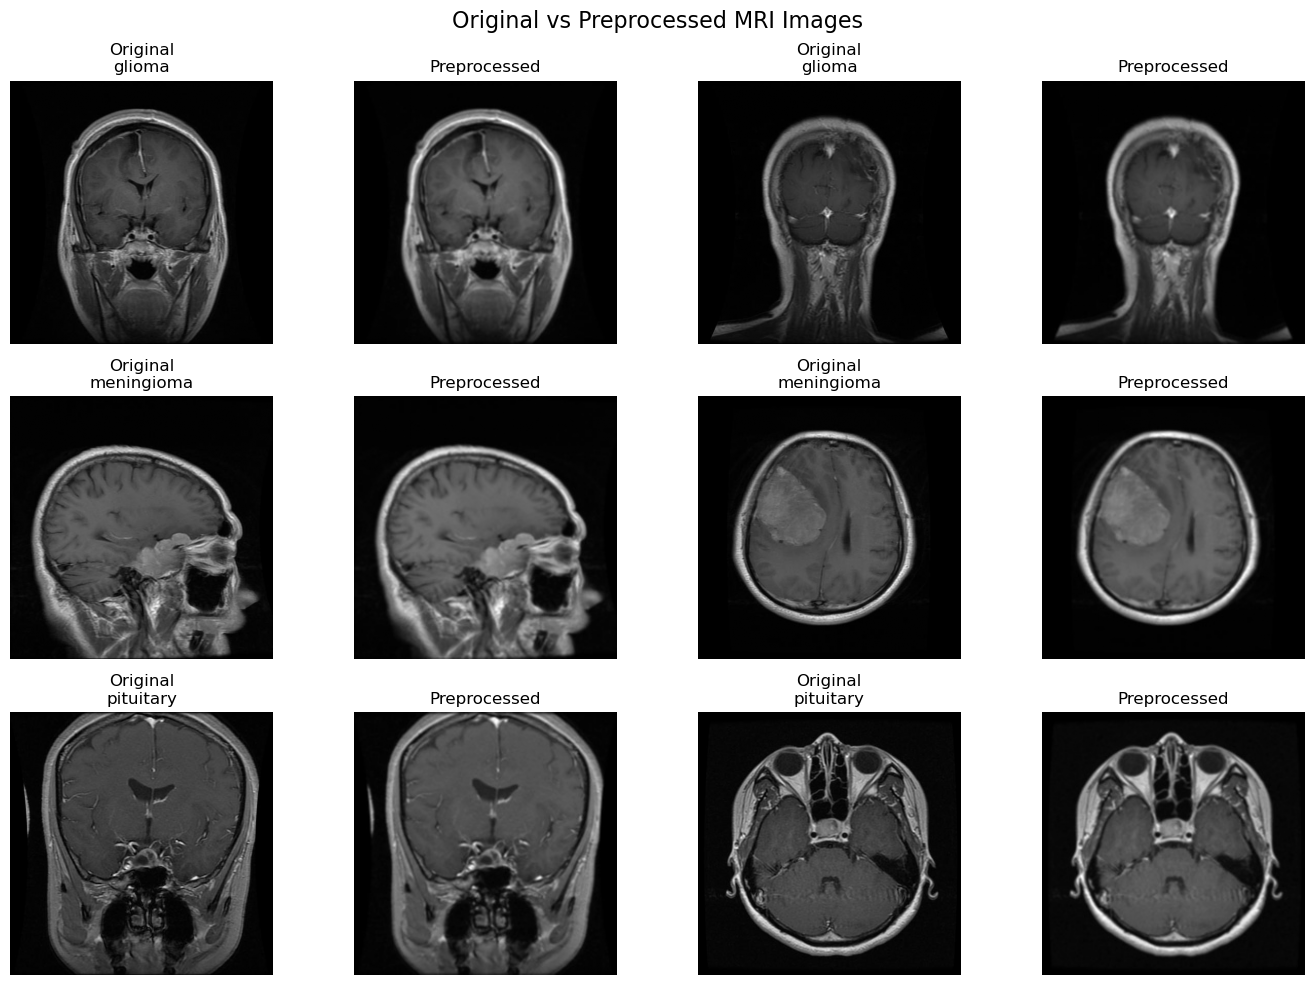

In [10]:
# ============================================================
# BLOCK 7: ORIGINAL vs PREPROCESSED IMAGE COMPARISON
# ============================================================
#
# This block randomly selects images from each tumor class
# and compares:
#
#       ORIGINAL MRI  |  PREPROCESSED MRI
#
# This allows us to visually verify the preprocessing result.
# ============================================================

import random


# ------------------------------------------------------------
# Number of samples per class
# ------------------------------------------------------------

NUM_SAMPLES = 2


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(train_classes),
    NUM_SAMPLES * 2,
    figsize=(14, 10)
)

fig.suptitle(
    "Original vs Preprocessed MRI Images",
    fontsize=16
)


# ------------------------------------------------------------
# Compare images class by class
# ------------------------------------------------------------

for row, class_folder in enumerate(train_classes):

    class_name = class_folder.name

    # Original class folder
    original_class_path = TRAIN_PATH / class_name

    # Preprocessed class folder
    processed_class_path = PREPROCESSED_TRAIN_PATH / class_name

    # Get original image files
    image_files = [
        file for file in original_class_path.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Randomly select images
    selected_images = random.sample(
        image_files,
        NUM_SAMPLES
    )

    # --------------------------------------------------------
    # Process selected images
    # --------------------------------------------------------

    for sample_index, original_path in enumerate(selected_images):

        # Corresponding preprocessed image
        processed_path = (
            processed_class_path /
            original_path.name
        )

        # Read original image as grayscale
        original_image = cv2.imread(
            str(original_path),
            cv2.IMREAD_GRAYSCALE
        )

        # Read preprocessed image
        processed_image = cv2.imread(
            str(processed_path),
            cv2.IMREAD_GRAYSCALE
        )

        # Column positions
        original_col = sample_index * 2
        processed_col = original_col + 1

        # ----------------------------------------------------
        # Display original
        # ----------------------------------------------------

        axes[row, original_col].imshow(
            original_image,
            cmap="gray"
        )

        axes[row, original_col].set_title(
            f"Original\n{class_name}"
        )

        axes[row, original_col].axis("off")

        # ----------------------------------------------------
        # Display preprocessed
        # ----------------------------------------------------

        axes[row, processed_col].imshow(
            processed_image,
            cmap="gray"
        )

        axes[row, processed_col].set_title(
            "Preprocessed"
        )

        axes[row, processed_col].axis("off")


plt.tight_layout()
plt.show()